# Import Libraries

In [1]:
!pip install numpy==1.26.4 scipy==1.11.4 statsmodels==0.14.2 pmdarima==2.0.4


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import pmdarima as pm

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [4]:
df = pd.read_csv('/content/household_power_consumption.csv')
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [5]:
# Combine Date and Time columns
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df = df.drop(columns=['Date','Time'])
df = df.set_index('datetime')

# Convert numeric columns
df = df.apply(pd.to_numeric, errors='coerce')

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# Resample & Handle Missing Values

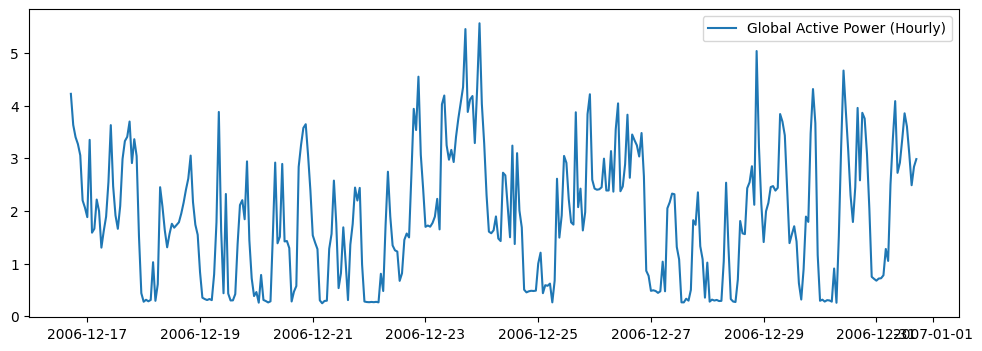

In [6]:
# Resample to hourly mean
df_hourly = df['Global_active_power'].resample('H').mean()
df_hourly = df_hourly.interpolate()

plt.figure(figsize=(12,4))
plt.plot(df_hourly, label='Global Active Power (Hourly)')
plt.legend()
plt.show()


# Train-Test Split

In [7]:
train = df_hourly[:-24*7]  # train: all but last 7 days
test = df_hourly[-24*7:]   # test: last 7 days
print("Train shape:", train.shape, "Test shape:", test.shape)

Train shape: (193,) Test shape: (168,)


#ARIMA Model

In [10]:
model = pm.auto_arima(train, seasonal=True, m=24, trace=True, suppress_warnings=True)
print(model.summary())

forecast_arima = model.predict(n_periods=len(test))
rmse_arima = mean_squared_error(test, forecast_arima) ** 0.5
mae_arima = mean_absolute_error(test, forecast_arima)
print(f'ARIMA -> RMSE: {rmse_arima:.3f}, MAE: {mae_arima:.3f}')


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=443.893, Time=5.74 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=463.796, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=456.384, Time=0.37 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=456.733, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=461.848, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=447.376, Time=2.18 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=445.668, Time=2.75 sec
 ARIMA(2,1,2)(2,0,1)[24] intercept   : AIC=445.887, Time=22.89 sec
 ARIMA(2,1,2)(1,0,2)[24] intercept   : AIC=445.887, Time=16.39 sec
 ARIMA(2,1,2)(0,0,0)[24] intercept   : AIC=453.144, Time=1.78 sec
 ARIMA(2,1,2)(0,0,2)[24] intercept   : AIC=447.098, Time=10.17 sec
 ARIMA(2,1,2)(2,0,0)[24] intercept   : AIC=445.415, Time=17.12 sec
 ARIMA(2,1,2)(2,0,2)[24] intercept   : AIC=inf, Time=21.79 sec
 ARIMA(1,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=5.68 sec
 ARIMA(2,1,1)(1,0,1)[24] intercept  

#Prophet Model

In [12]:
prophet_df = train.reset_index()
prophet_df.columns = ['ds','y']

m = Prophet(daily_seasonality=True)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=len(test), freq='H')
forecast = m.predict(future)

forecast_prophet = forecast.set_index('ds')['yhat'][-len(test):]
rmse_prophet = mean_squared_error(test, forecast_prophet) ** 0.5  # manually take sqrt
mae_prophet = mean_absolute_error(test, forecast_prophet)
print(f'Prophet -> RMSE: {rmse_prophet:.3f}, MAE: {mae_prophet:.3f}')


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5h8emg2c/ib_jpssg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5h8emg2c/ycas26d3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=46451', 'data', 'file=/tmp/tmp5h8emg2c/ib_jpssg.json', 'init=/tmp/tmp5h8emg2c/ycas26d3.json', 'output', 'file=/tmp/tmp5h8emg2c/prophet_modelrr_rlh84/prophet_model-20251005123755.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:37:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:37:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet -> RMSE: 2.764, MAE: 2.475


#XGBoost Model

In [14]:
# Feature engineering
df_feat = pd.DataFrame({'y': df_hourly})
df_feat['hour'] = df_feat.index.hour
df_feat['day'] = df_feat.index.day
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['lag1'] = df_feat['y'].shift(1)
df_feat['lag24'] = df_feat['y'].shift(24)
df_feat.dropna(inplace=True)

train_feat = df_feat.iloc[:-24*7]
test_feat = df_feat.iloc[-24*7:]

X_train = train_feat.drop(columns=['y'])
y_train = train_feat['y']
X_test = test_feat.drop(columns=['y'])
y_test = test_feat['y']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_xgb = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
model_xgb.fit(X_train_scaled, y_train)
pred_xgb = model_xgb.predict(X_test_scaled)

rmse_xgb = mean_squared_error(y_test, pred_xgb) ** 0.5
mae_xgb = mean_absolute_error(y_test, pred_xgb)
print(f'XGBoost -> RMSE: {rmse_xgb:.3f}, MAE: {mae_xgb:.3f}')


XGBoost -> RMSE: 0.924, MAE: 0.696


#Visualization

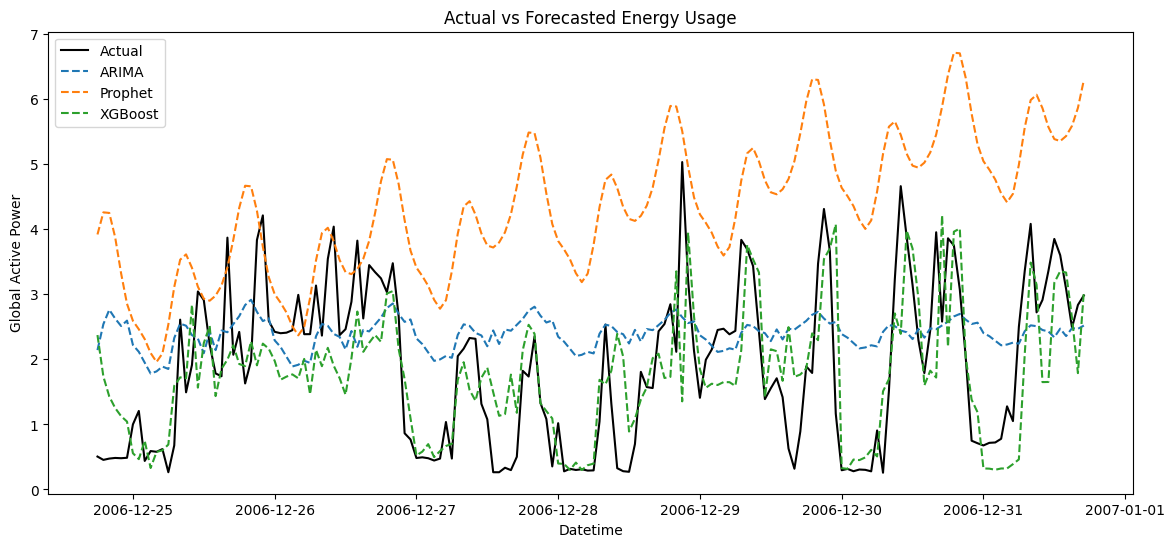

In [15]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test.values, label='Actual', color='black')
plt.plot(test.index, forecast_arima, label='ARIMA', linestyle='--')
plt.plot(test.index, forecast_prophet, label='Prophet', linestyle='--')
plt.plot(test.index, pred_xgb, label='XGBoost', linestyle='--')
plt.xlabel('Datetime')
plt.ylabel('Global Active Power')
plt.title('Actual vs Forecasted Energy Usage')
plt.legend()
plt.show()

# Final Comparison

In [18]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'RMSE': [rmse_arima, rmse_prophet, rmse_xgb],
    'MAE': [mae_arima, mae_prophet, mae_xgb]
})
print(results.sort_values('RMSE'))


     Model      RMSE       MAE
2  XGBoost  0.923978  0.695725
0    ARIMA  1.272543  1.079397
1  Prophet  2.764199  2.474807
